# 5. Confronto sperimentale tra modello ML e LLM

In questo notebook confronto la Logistic Regression polinomiale scelta per l'applicazione con un Large Language Model (LLM). L'obiettivo non è costruire un secondo strumento diagnostico, ma valutare in modo critico se un LLM, ricevendo gli stessi otto valori numerici, produce classificazioni coerenti con il test set e con il modello scikit-learn.

> **Limite importante.** Il dataset contiene osservazioni storiche e non dati di pazienti dell'applicazione. Il confronto ha finalità didattiche: nessuna delle due risposte costituisce diagnosi, prognosi o consiglio medico.

## Disegno dell'esperimento

Per mantenere il confronto corretto, ricostruisco la stessa divisione training/test stratificata usata nel progetto (`random_state=42`). La Logistic Regression viene addestrata soltanto sul training set e sia il modello ML sia l'LLM vengono valutati sulle stesse osservazioni del test set.

La valutazione finale usa tutte le 154 osservazioni del test set. In una prima esecuzione pilota su 24 record ho osservato una forte variabilità delle metriche della Logistic Regression: per non basare conclusioni su un campione troppo piccolo, mantengo lo stesso split stratificato ma valuto l'intero test set. L'esecuzione richiede più tempo perché ogni record viene inviato separatamente al modello linguistico.

In [43]:
from pathlib import Path
import os
import sys
import time
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from google import genai
from pydantic import BaseModel
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / '.env')
API_KEY_AVAILABLE = bool(os.getenv('GEMINI_API_KEY'))
MODEL_NAME = 'gemini-3.5-flash-lite'
N_CASES = None  # Usa tutte le 154 osservazioni del test set.
RUN_API_CALLS = False  # Impostare temporaneamente True soltanto per ripetere l'esperimento.
REQUEST_DELAY_SECONDS = 5  # Il Free Tier consente 15 richieste/minuto per questo modello.

print(f'Chiave API disponibile: {API_KEY_AVAILABLE}')
print(f'Modello LLM scelto: {MODEL_NAME}')
print(f'Numero di osservazioni previste: {N_CASES or 154}')

Chiave API disponibile: True
Modello LLM scelto: gemini-3.5-flash-lite
Numero di osservazioni previste: 154


Il file `.env` è locale e ignorato da Git. Il notebook verifica soltanto se la chiave è disponibile, senza stamparla. Ho scelto Gemini 3.5 Flash-Lite: è il modello leggero indicato dall'API per i nuovi utenti, rapido e adatto a classificazioni semplici nel Free Tier entro le relative quote. Il notebook registra il nome del modello restituito dall'API insieme ai risultati.

In [44]:
from src.config import FEATURE_COLUMNS, TARGET_COLUMN
from src.data import get_dataset
from src.train import final_model

data = get_dataset(download=False)
X = data[FEATURE_COLUMNS]
y = data[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

ml_model = final_model()
ml_model.fit(X_train, y_train)

if N_CASES is None:
    X_eval, y_eval = X_test.copy(), y_test.copy()
else:
    X_eval, _, y_eval, _ = train_test_split(
        X_test, y_test, train_size=N_CASES, stratify=y_test, random_state=42
    )

ml_probabilities = ml_model.predict_proba(X_eval)[:, 1]
ml_predictions = (ml_probabilities >= 0.5).astype(int)
evaluation = X_eval.copy()
evaluation['outcome_reale'] = y_eval
evaluation['predizione_ml'] = ml_predictions
evaluation['probabilita_ml'] = ml_probabilities

print(f'Training set: {len(X_train)} osservazioni')
print(f'Test set originale: {len(X_test)} osservazioni')
print(f'Campione LLM: {len(evaluation)} osservazioni')
evaluation.head()

Training set: 614 osservazioni
Test set originale: 154 osservazioni
Campione LLM: 154 osservazioni


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome_reale,predizione_ml,probabilita_ml
44,7,159,64,0,0,27.4,0.294,40,0,1,0.711154
672,10,68,106,23,49,35.5,0.285,47,0,0,0.157730
700,2,122,76,27,200,35.9,0.483,26,0,0,0.448170
630,7,114,64,0,0,27.4,0.732,34,1,0,0.427776
81,2,74,0,0,0,0.0,0.102,22,0,0,0.061181


## Prompt e risposta strutturata

Ogni osservazione viene inviata separatamente, senza rivelare l'etichetta reale né il nome del dataset di provenienza. Il prompt richiede una classificazione didattica basata soltanto sugli otto valori forniti e restituita in JSON. In questo modo evito di suggerire all'LLM il benchmark usato e riduco il rischio che faccia affidamento su conoscenze pregresse sul dataset invece di ragionare sui valori ricevuti.

La breve motivazione fornita dall'LLM viene conservata soltanto per l'analisi qualitativa: non è una spiegazione causale e non sostituisce le spiegazioni SHAP del notebook 4.

In [45]:
class LLMClassification(BaseModel):
    prediction: Literal[0, 1]
    reasoning: str

INSTRUCTIONS = '''
Sei parte di un esperimento accademico di classificazione binaria.
Riceverai otto variabili numeriche di una singola osservazione storica.
Basandoti esclusivamente sui valori forniti, assegna la classe 0 (rischio non elevato di diabete) oppure la classe 1 (rischio elevato di diabete).
Non usare fonti esterne, dataset di riferimento, esempi memorizzati o informazioni non contenute nei valori ricevuti.
Non formulare una diagnosi, non dare consigli medici e non aggiungere informazioni non richieste.
Restituisci esclusivamente il JSON richiesto; la motivazione deve essere breve e riferita ai valori ricevuti.
'''

def format_record(record: pd.Series) -> str:
    measurements = '\n'.join(f'- {column}: {record[column]:g}' for column in FEATURE_COLUMNS)
    return f'Osservazione da classificare:\n{measurements}'

def llm_predict(record: pd.Series, client) -> dict:
    response = client.interactions.create(
        model=MODEL_NAME,
        input=f'{INSTRUCTIONS}\n\n{format_record(record)}',
        response_format={
            'type': 'text',
            'mime_type': 'application/json',
            'schema': LLMClassification.model_json_schema(),
        },
    )
    result = LLMClassification.model_validate_json(response.output_text).model_dump()
    result['model'] = response.model
    return result

## Esecuzione controllata delle chiamate API

Le chiamate API sono disattivate per impostazione predefinita, perché la valutazione completa è già stata eseguita una volta e i risultati sono mostrati nelle celle seguenti. Per ripetere l'esperimento imposto temporaneamente `RUN_API_CALLS = True` dopo avere verificato che `API_KEY_AVAILABLE` sia `True`. Il risultato viene salvato localmente in `reports/llm_full_test_results.csv`, mentre un file parziale protegge il lavoro in caso di interruzione. Il Free Tier Gemini applica un limite di 15 richieste al minuto per questo modello: il notebook attende cinque secondi tra due record. L'esecuzione dell'intero test set di 154 record richiede quindi circa tredici minuti.

In [46]:
if RUN_API_CALLS:
    if not API_KEY_AVAILABLE:
        raise RuntimeError('Chiave assente: aggiungere GEMINI_API_KEY al file .env locale.')

    client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))
    llm_results = []
    output_path = PROJECT_ROOT / 'reports' / 'llm_full_test_results.csv'
    partial_path = PROJECT_ROOT / 'reports' / 'llm_partial_results.csv'
    output_path.parent.mkdir(parents=True, exist_ok=True)

    for position, (index, record) in enumerate(evaluation.iterrows(), start=1):
        try:
            result = llm_predict(record, client)
        except Exception as exc:
            if llm_results:
                pd.DataFrame(llm_results).set_index('index').to_csv(partial_path, index=True)
            raise RuntimeError(
                f'Chiamata interrotta dopo {len(llm_results)} record. '
                f'Le risposte parziali sono state salvate in {partial_path.relative_to(PROJECT_ROOT)}. '
                "Attendere il tempo indicato dall'API e riprovare."
            ) from exc

        result['index'] = index
        llm_results.append(result)
        pd.DataFrame(llm_results).set_index('index').to_csv(partial_path, index=True)
        print(f'Record {position}/{len(evaluation)} completato.')
        if position < len(evaluation):
            time.sleep(REQUEST_DELAY_SECONDS)

    llm_results = pd.DataFrame(llm_results).set_index('index').reindex(evaluation.index)
    comparison_data = evaluation.join(llm_results.add_prefix('llm_'))
    comparison_data.to_csv(output_path, index=True)
    partial_path.unlink(missing_ok=True)
    print(f'Risultati salvati in: {output_path.relative_to(PROJECT_ROOT)}')
else:
    output_path = PROJECT_ROOT / 'reports' / 'llm_full_test_results.csv'
    if output_path.exists():
        comparison_data = pd.read_csv(output_path, index_col=0)
        print(f'Risultati completi già disponibili: {len(comparison_data)} record.')
    else:
        print('Risultati locali non trovati. Impostare RUN_API_CALLS = True soltanto per ripetere l’esperimento.')

Risultati completi già disponibili: 154 record.


## Confronto quantitativo

Confronto accuracy, precision, recall e F1-score delle due strategie sullo stesso test set. La confusion matrix permette inoltre di osservare direttamente falsi positivi e falsi negativi. Mostro anche la ROC-AUC della Logistic Regression, perché il modello restituisce una probabilità continua. Gemini restituisce invece soltanto una classe e una breve motivazione: non dispone quindi di un punteggio continuo comparabile e la sua ROC-AUC viene indicata come non disponibile.

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modello,,,,,
Logistic Regression,0.734,0.607,0.685,0.643,0.825
Gemini LLM,0.714,0.583,0.648,0.614,Non disponibile


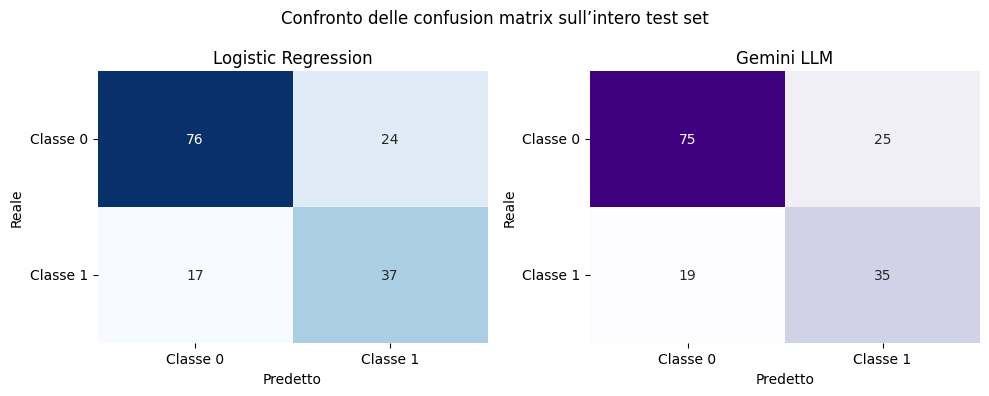

In [47]:
if 'comparison_data' in globals():
    y_true = comparison_data['outcome_reale']
    y_ml = comparison_data['predizione_ml']
    y_llm = comparison_data['llm_prediction']

    def metric_row(name, y_pred, scores=None):
        row = {
            'Modello': name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1-score': f1_score(y_true, y_pred, zero_division=0),
        }
        row['ROC-AUC'] = roc_auc_score(y_true, scores) if scores is not None else np.nan
        return row

    metrics_comparison = pd.DataFrame([
        metric_row('Logistic Regression', y_ml, comparison_data['probabilita_ml']),
        metric_row('Gemini LLM', y_llm),
    ]).set_index('Modello')
    display(metrics_comparison.style.format('{:.3f}', na_rep='Non disponibile'))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for axis, predictions, title, color in [
        (axes[0], y_ml, 'Logistic Regression', 'Blues'),
        (axes[1], y_llm, 'Gemini LLM', 'Purples'),
    ]:
        sns.heatmap(confusion_matrix(y_true, predictions), annot=True, fmt='d', cmap=color, cbar=False, ax=axis)
        axis.set_title(title)
        axis.set_xlabel('Predetto')
        axis.set_ylabel('Reale')
        axis.set_xticklabels(['Classe 0', 'Classe 1'])
        axis.set_yticklabels(['Classe 0', 'Classe 1'], rotation=0)
    fig.suptitle('Confronto delle confusion matrix sull’intero test set')
    fig.tight_layout()
    plt.show()
else:
    print('Risultati locali non trovati: eseguire la sezione precedente con RUN_API_CALLS = True.')

## Analisi dei casi discordanti

Questa tabella mostra i record in cui l'LLM e la Logistic Regression non coincidono. La colonna con la motivazione dell'LLM aiuta a discutere il suo comportamento linguistico, mentre la probabilità ML e le spiegazioni SHAP restano gli strumenti quantitativi del progetto.

In [48]:
if 'comparison_data' in globals():
    disagreements = comparison_data.loc[
        comparison_data['predizione_ml'] != comparison_data['llm_prediction'],
        ['outcome_reale', 'predizione_ml', 'probabilita_ml', 'llm_prediction', 'llm_reasoning']
    ]
    print(f'Casi discordanti: {len(disagreements)} su {len(comparison_data)}')
    with pd.option_context('display.max_colwidth', None, 'display.max_rows', 30):
        display(disagreements)
else:
    print('Risultati locali non trovati: eseguire la sezione precedente con RUN_API_CALLS = True.')

Casi discordanti: 13 su 154


,outcome_reale,predizione_ml,probabilita_ml,llm_prediction,llm_reasoning
745,0,0,0.462207,1,"L'elevato numero di gravidanze (12) combinato con un'età avanzata (46) e un indice di massa corporea (BMI) pari a 30, associati a valori moderati di glucosio e insulina, configurano un profilo di rischio complessivamente elevato per il diabete."
560,1,1,0.513403,0,"Nonostante l'età avanzata (54 anni) e un BMI elevato (33.8), il livello di glucosio (125) è moderato e il diabetes pedigree function è molto basso (0.121), indicando un rischio complessivo non elevato secondo i parametri standard."
351,0,0,0.483237,1,Valori elevati di glucosio (137) e BMI (31.2) associati all'età e al numero di gravidanze indicano un rischio elevato secondo i parametri standard di classificazione.
618,1,1,0.648958,0,"Despite advanced age, high parity, and a high pedigree function, the moderate glucose and BMI levels, combined with zero insulin and normal blood pressure, indicate a non-elevated risk classification."
243,1,1,0.514998,0,"Nonostante la presenza di un valore elevato per il diabetes pedigree (1.318), il livello di glucosio (119) e l'indice di massa corporea (27.1) rientrano in intervalli moderati che, combinati con l'età di 33 anni, non superano la soglia critica per la classificazione a rischio elevato nel modello standard."
698,0,1,0.505300,0,"Nonostante la presenza di alcuni valori moderatamente elevati come il glucosio (127) e il BMI (34.5), la combinazione complessiva dei parametri rientra in un profilo di rischio non elevato sulla base dei dati forniti."
304,0,0,0.378250,1,"Il valore elevato della glicemia (150) supera significativamente la soglia di normalità ed è un forte indicatore di rischio per il diabete, nonostante gli altri parametri siano nella norma."
330,0,1,0.538316,0,"Nonostante il numero elevato di gravidanze e il pedigree del diabete alto, il valore della glicemia moderato (118) e il BMI basso (23.1) suggeriscono un rischio non elevato sulla base dei parametri combinati."
584,1,0,0.492126,1,Il livello estremamente alto di insulina (600) associato a un'età avanzata (52 anni) e a un numero elevato di gravidanze (8) indica un rischio elevato di diabete.
164,1,0,0.467504,1,"Il valore del glucosio (131) è moderatamente elevato e, combinato con un BMI di 31.6 e un indice di familiarità (diabetes_pedigree) di 0.743, indica un profilo di rischio più elevato."


## Conclusioni

> **Esito del confronto:** la **Logistic Regression polinomiale** resta il modello preferito per l'applicazione.

Sul test set completo di 154 osservazioni, la Logistic Regression polinomiale ottiene accuracy **73,4%**, precision **60,7%**, recall **68,5%**, F1-score **64,4%** e ROC-AUC **82,5%**. Gemini 3.5 Flash-Lite raggiunge accuracy **71,4%**, precision **58,3%**, recall **64,8%** e F1-score **61,4%**. I due approcci concordano in **141 casi su 154** e producono classificazioni diverse nei restanti 13. La Logistic Regression ottiene comunque valori migliori in tutte le metriche confrontabili e riconosce più casi positivi: **37 veri positivi contro 35**.

Le confusion matrix confermano questa differenza: Gemini produce **25 falsi positivi e 19 falsi negativi**, mentre la Logistic Regression ne produce rispettivamente **24 e 17**. Il modello ML commette quindi meno errori di entrambi i tipi in questa valutazione. La ROC-AUC è disponibile solo per la Logistic Regression, poiché usa probabilità numeriche; Gemini restituisce una classe e non un punteggio continuo confrontabile.

Il modello ML rimane quello operativo dell'applicazione: viene eseguito localmente, è rapido, riproducibile e le sue trasformazioni sono documentate e analizzabili con SHAP. Gemini è invece un approfondimento sperimentale che richiede una chiave API, dipende da un servizio esterno e invia dati a tale servizio. Nel prompt finale non ho comunicato il nome del dataset, le etichette reali, un URL o strumenti di ricerca web; tuttavia PIMA è pubblico e non posso escludere che il modello linguistico ne abbia incontrato esempi durante il proprio addestramento. Inoltre l'istruzione di non usare conoscenze memorizzate non è verificabile dall'esterno. Per questi motivi il confronto è illustrativo e non dimostra una capacità diagnostica o di generalizzazione clinica.